### Lab IV: Linear Models
### Answer all three sets of questions

#### Turn in one python file for the three computation questions and one text file for Q0

**Q0.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?

A model is linear when the coeifficients are linear. his means the coefficients are multiplied by variables and added together, and are not multiplied by each other or raised to powers.

2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (This is a trick question, and the trick involves how you handle the intercept of the model.) There's further explanation at the end of this document, if needed.

You interpert the difference in the predicted outcome between that category and the reference category, assuming all other variables stay consistent.

3. Can linear regression be used for classification? Explain why, or why not.

Linear regression cannot be used for classification because it predicts continuous numerical and classification requires discrete categories. 

4. If you have a high accuracy on training but low on testing, what might be the problem? It also might be you see a pattern in the residuals. 

If you have a high accauarcy on training but on testing the problem could be overfitting. There is likely not enough training data, too many features being analyzed or the model is complex. 

5. Review this page: [Non-Linear with Linear](https://inria.github.io/scikit-learn-mooc/python_scripts/linear_regression_non_linear_link.html) What are two ways to incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$?

You can incorperate nonlinear relationships between varaibles and features by including expert knowledge which can be directly used by a simple linear model, or using a “kernel” to have a locally-based decision function instead of a global linear decision function.

6. What is the interpretation of the intercept? A slope coefficient for a variable? The coefficient for a dummy/one-hot-encoded variable?

The intercept is the predicted value of the target variable when all predictor variables are equal to zero. A slope coefficient is the expected change in the target variable for a 1 unit increase in the predictor variable, while other variables stay consistent. The coefficient dummy variable is the difference predicted value between that category and the reference category.

**Q1.** Load clean q1_clean: https://raw.githubusercontent.com/DS3001/linearRegression/refs/heads/main/data/Q1_clean.csv 

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

housing_data = pd.read_csv('Q1_clean.csv')
housing_data.info() 
# allows us to learn the shape of object types of our data

<class 'pandas.DataFrame'>
RangeIndex: 22153 entries, 0 to 22152
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Price                 22153 non-null  int64  
 1   Review Scores Rating  22153 non-null  float64
 2   Neighbourhood         22153 non-null  str    
 3   Property Type         22153 non-null  str    
 4   Room Type             22153 non-null  str    
dtypes: float64(1), int64(1), str(3)
memory usage: 865.5 KB


In [61]:
housing_data.head(5)
# prints the first 5 rows of our data to get a better understanding of what it looks like

,Price,Review Scores Rating,Neighbourhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt


In [62]:
housing_data.describe()
# gives us a statistical summary of our data, including count, mean, std, min, etc.

,Price,Review Scores Rating
count,22153.000000,22153.000000
mean,154.787388,91.993093
std,148.843320,8.850658
min,10.000000,20.000000
25%,85.000000,89.000000
50%,125.000000,94.000000
75%,190.000000,100.000000
max,10000.000000,100.000000


In [63]:
housing_data.columns = housing_data.columns.str.strip()
# removes any leading or trailing whitespace from the column names to ensure they are clean and consistent

The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighborhood `: The bourough of NYC. Note the space, or rename the variable.
- `Property Type`: The kind of dwelling
- `Room Type`: The kind of space being rented

1. Compute the average prices and scores by `Neighborhood `; which borough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighborhood `.

In [64]:
housing_data.groupby('Neighbourhood')[['Price', 'Review Scores Rating']].mean().sort_values(by='Price', ascending=False)
# shows us the average price and review score for each neighborhood


,Price,Review Scores Rating
Neighbourhood,,
Manhattan,183.664286,91.801496
Staten Island,146.166667,90.843750
Brooklyn,127.747378,92.363497
Queens,96.857233,91.549057
Bronx,75.276498,91.654378


The most expensive borough is Manhattan at the price of 183.664286.

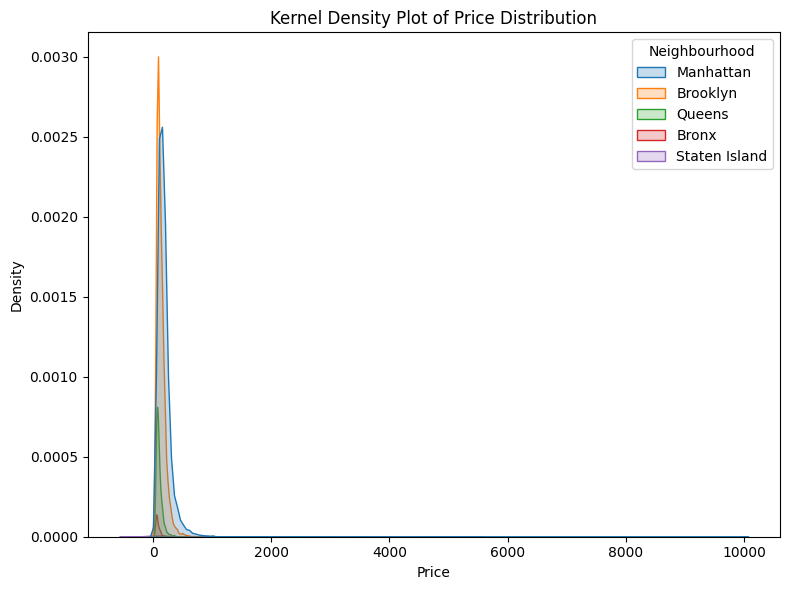

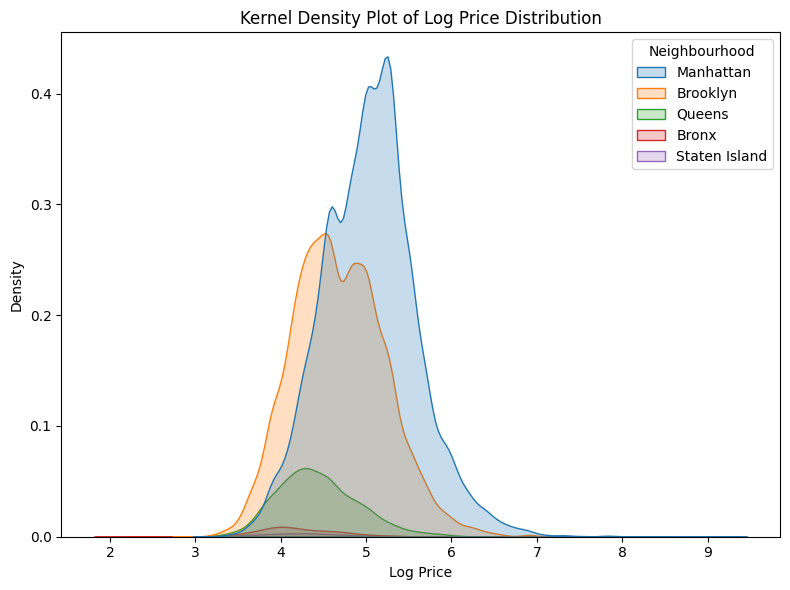

In [65]:
# kernel density plot of price distribution
plt.figure(figsize=(8, 6))
sns.kdeplot(housing_data, x='Price', hue='Neighbourhood', fill=True)
# hue is the grouping variable, it tells seaborn to create separate density plots for each neighborhood and the color specifies each density plots
plt.title('Kernel Density Plot of Price Distribution')
plt.xlabel('Price')
plt.ylabel('Density')

plt.tight_layout()
plt.show()

housing_data['log_price'] = np.log(housing_data['Price'])
# we are creating a new column called 'log_price' in our housing_data DataFrame, which contains the natural logarithm of the 'Price' column

plt.figure(figsize=(8, 6))
sns.kdeplot(housing_data, x='log_price', hue='Neighbourhood', fill=True)
# hue is the grouping variable, it tells seaborn to create separate density plots for each neighborhood and the color specifies each density plots
plt.title('Kernel Density Plot of Log Price Distribution')
plt.xlabel('Log Price')
plt.ylabel('Density')  

plt.tight_layout()
plt.show()

2. Regress price on `Neighborhood ` by creating the appropriate dummy/one-hot-encoded variables, without an intercept in the linear model. Compare the coefficients in the regression to the table from part 1. What pattern do you see? What are the coefficients in a regression of a continuous variable on one categorical variable?

In [66]:
housing_data_dummies = pd.get_dummies(housing_data, columns=['Neighbourhood'], drop_first=False, dtype='float')
# drop_first=False because there is an intercept term in the linear regression model

# housing_data_dummies.head(6), showed me the names of the columns after creating dummies

X = housing_data_dummies[['Neighbourhood_Bronx','Neighbourhood_Brooklyn','Neighbourhood_Manhattan','Neighbourhood_Queens','Neighbourhood_Staten Island']]
# we are selecting the dummy variables for the neighborhoods as our independent variables (X) 
Y = housing_data_dummies['Price']
# the price as our dependent variable (Y)

from sklearn.linear_model import LinearRegression
model = LinearRegression(fit_intercept=False)
# the fit_intercept=False argument is used to indicate that we do not want to include an intercept term in our linear regression model 
model.fit(X, Y)
# the fit method is used to train the linear regression model on our data, where X is the independent variable and Y is the dependent variable

print(model.coef_)
# the underscore in model.coef_ is used to access the coefficients of the linear regression model

[ 75.2764977  127.74737834 183.66428632  96.8572327  146.16666667]


The pattern I see is that the prices for each neighbourhood match the ones from when we found the average prices and scores by neighbourhoods. The coefficients in a regression of a continous variable on one categorical variable is representing the average price for that neighbourhood.

3. Repeat part 2, but leave an intercept in the linear model. How do you have to handle the creation of the dummies differently? What is the intercept? Interpret the coefficients. How can I get the coefficients in part 2 from these new coefficients?

In [67]:
housing_data_dummies = pd.get_dummies(housing_data, columns=['Neighbourhood'], drop_first=True, dtype='float')
# drop_first=True to avoid the dummy variable trap

X = housing_data_dummies[['Neighbourhood_Brooklyn','Neighbourhood_Manhattan','Neighbourhood_Queens','Neighbourhood_Staten Island']]
# we are selecting the dummy variables for the neighborhoods as our independent variables (X) 
Y = housing_data_dummies['Price']
# the price as our dependent variable (Y)

from sklearn.linear_model import LinearRegression
model = LinearRegression(fit_intercept=True)
# the fit_intercept=False argument is used to indicate that we do not want to include an intercept term in our linear regression model 
model.fit(X, Y)
# the fit method is used to train the linear regression model on our data, where X is the independent variable and Y is the dependent variable

print(model.coef_)
# the underscore in model.coef_ is used to access the coefficients of the linear regression model
print(X.columns)
# this prints the names of the columns in X, which are the independent variables used in our linear regression model

[ 52.47088065 108.38778863  21.58073501  70.89016897]
Index(['Neighbourhood_Brooklyn', 'Neighbourhood_Manhattan',
       'Neighbourhood_Queens', 'Neighbourhood_Staten Island'],
      dtype='str')


I created the dummies the same way, except this time I made the drop_first=True so that we can avoid the dummy variable trap, which drops the Bronx as the reference category. The intercept is the predicted value of the target variable when all predictor variables are equal to zero. The coefficients are lower than before because they now show the difference in average price compared to the Bronx. You can add the intercepts to each coefficient to get back the coefficients in part 2.

4. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighborhood `. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?

In [68]:
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
 
housing_data_dummies = pd.get_dummies(housing_data, columns=['Neighbourhood'], drop_first=True, dtype='float')
# drop_first=True to avoid the dummy variable trap

X = housing_data_dummies[['Review Scores Rating', 'Neighbourhood_Brooklyn', 'Neighbourhood_Manhattan', 'Neighbourhood_Queens', 'Neighbourhood_Staten Island']]
# we are selecting the review scores rating and dummy variables for the neighborhoods as our independent variables (X)
Y = housing_data_dummies['Price']
# the price as our dependent variable (Y)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = .20, random_state = 40)
# creating training and testing sets for our data, where test_size=.20 indicates that 20% of the data will be used for testing and random_state=40 ensures that the split is reproducible

model = linear_model.LinearRegression()
# linear regression model is trained on the training data (X_train and Y_train) and then used to make predictions on the test data (X_test)
model.fit(X_train, Y_train)
# the fit method is used to train the linear regression model on the training data, where X_train is the independent variable and Y_train is the dependent variable
predicted = model.predict(X_test)
# the predicted variable contains the predicted prices for the test data based on the linear regression model

print('R2 Score (Testing):', r2_score(Y_test, predicted))
# the r2_score function is used to evaluate the performance of the linear regression model
print(' Root Mean Squared Error (Testing):', np.sqrt(mean_squared_error(Y_test, predicted)))
# prints the mean squared error of the predictions, which is a measure of how well the model's predictions match the actual values in the test set

print(model.coef_)
# the underscore in model.coef_ is used to access the coefficients of the linear regression model
print(X.columns)
# the coefficients represent the estimated effect of each independent variable 

R2 Score (Testing): 0.08230721172544131
 Root Mean Squared Error (Testing): 106.28986886521714
[  1.02750916  52.04910635 109.3336238   21.62439234  88.97970347]
Index(['Review Scores Rating', 'Neighbourhood_Brooklyn',
       'Neighbourhood_Manhattan', 'Neighbourhood_Queens',
       'Neighbourhood_Staten Island'],
      dtype='str')


The r2 for the test set is 0.08230721172544131. The RMSE for the test set is 106.28986886521714. The coefficient of `Review Scores Rating` is 1.02750916. The most expensive kind of property you can rent is in Manhattan because it is $109.3336238 more than the Bronx, the reference category.

5. Run a regression of `Price` on `Review Scores Rating` and `Neighborhood ` and `Property Type`. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?

In [69]:
housing_data_dummies = pd.get_dummies(housing_data, columns=['Neighbourhood', 'Property Type'], drop_first=True, dtype='float')
# housing_data_dummies.head(6) to see the property type columns

X = housing_data_dummies[[ 'Review Scores Rating', 'Neighbourhood_Brooklyn', 'Neighbourhood_Manhattan', 'Neighbourhood_Queens', 'Neighbourhood_Staten Island', 'Property Type_Bed & Breakfast', 
                        'Property Type_Boat', 'Property Type_Bungalow', 'Property Type_Cabin', 'Property Type_Camper/RV', 'Property Type_Castle', 'Property Type_Chalet', 'Property Type_Condominium', 
                        'Property Type_Dorm', 'Property Type_House', 'Property Type_Hut', 'Property Type_Lighthouse', 'Property Type_Loft', 'Property Type_Other', 'Property Type_Townhouse', 'Property Type_Treehouse'
                        ,'Property Type_Villa']]
# we are selecting the review scores rating, dummy variables for the neighborhoods, and dummy variables for the property types as our independent variables (X)
Y = housing_data_dummies['Price']
# the price as our dependent variable (Y)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = .20, random_state = 40)
# creating training and testing sets for our data, where test_size=.20 indicates that 20% of the data will be used for testing and random_state=40 ensures that the split is reproducible

model = linear_model.LinearRegression()
# linear regression model is trained on the training data (X_train and Y_train) and then used to make predictions on the test data (X_test)
model.fit(X_train, Y_train)
# the fit method is used to train the linear regression model on the training data, where X_train is the independent variable and Y_train is the dependent variable
predicted = model.predict(X_test)
# the predicted variable contains the predicted prices for the test data based on the linear regression model

print('R2 Score (Testing):', r2_score(Y_test, predicted))
# the r2_score function is used to evaluate the performance of the linear regression model
print('Root Mean Squared Error (Testing):', np.sqrt(mean_squared_error(Y_test, predicted)))
# prints the mean squared error of the predictions, which is a measure of how well the model's predictions match the actual values in the test set

print(model.coef_)
# the underscore in model.coef_ is used to access the coefficients of the linear regression model
print(X.columns)
# the coefficients represent the estimated effect of each independent variable
print('Most expensive property type:',str(X.columns[2]) + ": " + str(model.coef_[2]))
# used indexing to find the most expensive property type based on the coefficient values

R2 Score (Testing): 0.08534318021973553
Root Mean Squared Error (Testing): 106.11390582635056
[   1.01681137   60.47317693  123.42997013   28.38299784   82.3286457
  -30.01664281   81.36450192   28.57319701   35.16739045  -15.56782596
  -41.08304917  -28.1094446   102.5068739   -49.65442857   36.09262338
 -134.98218096  -89.12625597   67.01091959   -7.44734694   86.58686941
  -76.87290706   34.58555853]
Index(['Review Scores Rating', 'Neighbourhood_Brooklyn',
       'Neighbourhood_Manhattan', 'Neighbourhood_Queens',
       'Neighbourhood_Staten Island', 'Property Type_Bed & Breakfast',
       'Property Type_Boat', 'Property Type_Bungalow', 'Property Type_Cabin',
       'Property Type_Camper/RV', 'Property Type_Castle',
       'Property Type_Chalet', 'Property Type_Condominium',
       'Property Type_Dorm', 'Property Type_House', 'Property Type_Hut',
       'Property Type_Lighthouse', 'Property Type_Loft', 'Property Type_Other',
       'Property Type_Townhouse', 'Property Type_Treehouse

The r2 for the test set is 0.08534318021973553. The RMSE for the test set is 106.11390582635056. The coefficient of `Review Scores Rating` is 1.01681137. The most expensive kind of property you can rent is a condominium it is $123.42997012986761 more than the bronx (reference category).

6. What does the coefficient on `Review Scores Rating` mean if it changes from part 4 to 5? Hint: Think about how multiple linear regression works.

In multiple linear regression, each coefficient represents the effect of that variable holding all other variables constant. So the coefficient change means that once we control for property type, the effect of review scores on price is slightly different.

7. (Optional) We've included `Neighborhood ` and `Property Type` separately in the model. How do you interact them, so you can have "A bedroom in Queens" or "A townhouse in Manhattan". Split the sample 80/20 into a training and a test set and run a regression including that kind of "property type X neighborhood" dummy, plus `Review Scores Rating`. How does the slope coefficient for `Review Scores Rating`, the $R^2$, and the RMSE change? Do they increase significantly compares to part 5? Are the coefficients in this regression just the sum of the coefficients for `Neighbourhood ` and `Property Type` from 5? What is the most expensive kind of property you can rent?

**Q2.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`, `Color`, `Seating_Capacity`
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make`, `Make_Year`: The brand of car and year produced
  - `Mileage_Run`: The number of miles on the odometer
  - `Fuel_Type`: Diesel or gasoline/petrol
  - `Transmission`, `Transmission_Type`:  speeds and automatic/manual

  1. Load `cars_hw.csv`. These data were really dirty, and I've already cleaned them a significant amount in terms of missing values and other issues, but some issues remain (e.g. outliers, badly skewed variables that require a log or arcsinh transformation) Note this is different than normalizing: there is a text below that explains further. Clean the data however you think is most appropriate.
  

In [70]:
cars_hw = pd.read_csv('cars_hw.csv')

cars_hw.info()
# allows us to learn the shape of object types of our data

<class 'pandas.DataFrame'>
RangeIndex: 976 entries, 0 to 975
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Unnamed: 0         976 non-null    int64
 1   Make               976 non-null    str  
 2   Make_Year          976 non-null    int64
 3   Color              976 non-null    str  
 4   Body_Type          976 non-null    str  
 5   Mileage_Run        976 non-null    int64
 6   No_of_Owners       976 non-null    str  
 7   Seating_Capacity   976 non-null    int64
 8   Fuel_Type          976 non-null    str  
 9   Transmission       976 non-null    str  
 10  Transmission_Type  976 non-null    str  
 11  Price              976 non-null    int64
dtypes: int64(5), str(7)
memory usage: 91.6 KB


In [71]:
cars_hw.head(5)
# prints the first 5 rows of our data to get a better understanding of what it looks like

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


In [72]:
cars_hw.describe()
# gives us a statistical summary of our data, including count, mean, std, min, etc.

,Unnamed: 0,Make_Year,Mileage_Run,Seating_Capacity,Price
count,976.000000,976.000000,976.000000,976.000000,9.760000e+02
mean,488.500000,2016.963115,41571.195697,5.095287,7.410195e+05
std,281.891232,2.818742,24390.995134,0.446224,3.673234e+05
min,1.000000,2011.000000,1117.000000,4.000000,1.880000e+05
25%,244.750000,2015.000000,22676.750000,5.000000,4.757500e+05
50%,488.500000,2017.000000,37570.500000,5.000000,6.665000e+05
75%,732.250000,2019.000000,57421.250000,5.000000,8.830000e+05
max,976.000000,2022.000000,99495.000000,8.000000,2.941000e+06


In [73]:
cars_hw['Transmission'] = cars_hw['Transmission'].str.extract('(\d+)').astype(float)
# takes away the text and leaves the number 

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_33005/402869715.py:1: SyntaxWarning: invalid escape sequence '\d'
  cars_hw['Transmission'] = cars_hw['Transmission'].str.extract('(\d+)').astype(float)


In [74]:
cars_hw['No_of_Owners'] = cars_hw['No_of_Owners'].str.extract('(\d+)').astype(float)

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_33005/890287684.py:1: SyntaxWarning: invalid escape sequence '\d'
  cars_hw['No_of_Owners'] = cars_hw['No_of_Owners'].str.extract('(\d+)').astype(float)


2. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by brand (`Make`). Make a grouped kernel density plot by `Make`. Which car brands are the most expensive? What do prices look like in general?

In [75]:
cars_hw.groupby('Make')[['Price']].describe().sort_values(by=('Price', 'mean'), ascending=False)
# shows us the average price and review score for each neighborhood 

Price                                                    \
               count          mean           std        min        25%   
Make                                                                     
MG Motors       35.0  1.869457e+06  1.216611e+05  1589000.0  1786500.0   
Kia              8.0  1.614750e+06  1.190567e+05  1369000.0  1579000.0   
Jeep             4.0  1.499500e+06  1.525134e+05  1290000.0  1447500.0   
Skoda            5.0  1.136000e+06  1.070175e+06   436000.0   466000.0   
Mahindra        18.0  1.100167e+06  1.755493e+05   796000.0  1037000.0   
Tata            23.0  1.055217e+06  5.578305e+05   188000.0   779500.0   
Nissan           4.0  8.842500e+05  2.895599e+05   475000.0   782500.0   
Toyota          50.0  8.003400e+05  2.466900e+05   368000.0   526250.0   
Honda           73.0  7.989726e+05  2.665091e+05   316000.0   581000.0   
Ford            52.0  7.211731e+05  1.409277e+05   290000.0   635000.0   
Hyundai        305.0  6.918918e+05  2.791597e+05   248000.0   485000.0   
Renault         68.0  6.625735e+05  2.148273e+05   287000.0   475000.0   
Volkswagen      29.0  6.058276e+05  1.198312e+05   402000.0   542000.0   
Maruti Suzuki  293.0  5.887850e+05  2.160199e+05   237000.0   411000.0   
Chevrolet        6.0  4.535000e+05  2.466064e+05   267000.0   288500.0   
Datsun           3.0  2.896667e+05  1.050397e+04   279000.0   284500.0   

                                                
                     50%        75%        max  
Make                                            
MG Motors      1848000.0  1978000.0  2019000.0  
Kia            1628500.0  1705750.0  1741000.0  
Jeep           1529500.0  1581500.0  1649000.0  
Skoda           538000.0  1299000.0  2941000.0  
Mahindra       1094500.0  1157000.0  1465000.0  
Tata            869000.0  1552000.0  2100000.0  
Nissan          978000.0  1079750.0  1106000.0  
Toyota          894000.0  1023000.0  1092000.0  
Honda           785000.0   915000.0  1537000.0  
Ford            707500.0   787000.0  1066000.0  
Hyundai         638000.0   837000.0  1742000.0  
Renault         644000.0   801000.0  1164000.0  
Volkswagen      607000.0   699000.0   790000.0  
Maruti Suzuki   527000.0   764000.0  1163000.0  
Chevrolet       345500.0   537500.0   892000.0  
Datsun          290000.0   295000.0   300000.0

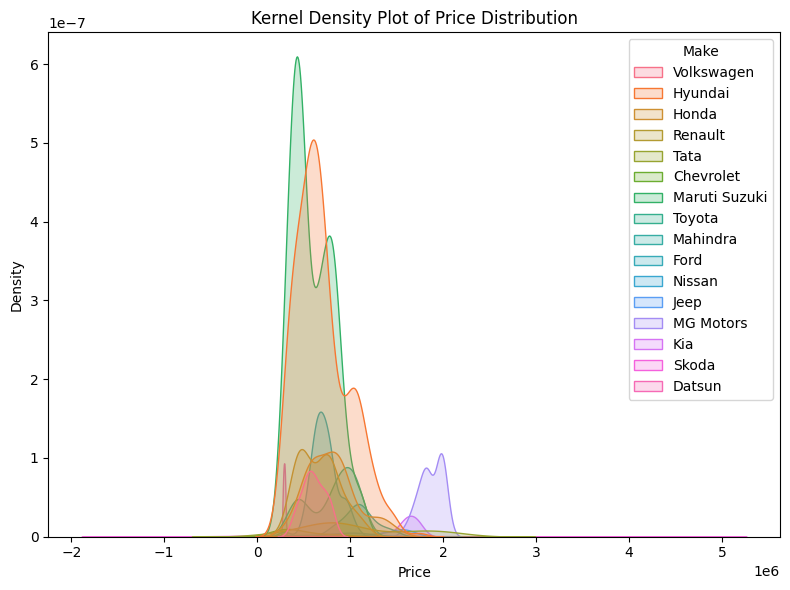

In [76]:
# kernel density plot of price distribution
plt.figure(figsize=(8, 6))
sns.kdeplot(cars_hw, x='Price', hue='Make', fill=True)
# hue is the grouping variable, it tells seaborn to create separate density plots for each neighborhood and the color specifies each density plots
plt.title('Kernel Density Plot of Price Distribution')
plt.xlabel('Price')
plt.ylabel('Density')

plt.tight_layout()
plt.show()

The most expensive car brands are MG Motors, Kia, Jeep, Skoda, Mahindra, and Tata. The expensive brands like MG Motors and Kia appear further to the right on the plot and are less dense, meaning fewer cars are sold at those higher prices. I also noticed that these car brands are not usually as expensive in the US, but I reviewed the data and it could just be because it's from a different country. 

 3. Split the data into an 80% training set and a 20% testing set.

In [77]:
X = cars_hw.drop(columns=['Price'])
# we are selecting the dummy variables for the car makes as our independent variables (X)
Y = cars_hw['Price']
# the price as our dependent variable (Y)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.20, random_state=40)
# creating training and testing sets for our data, where test_size=.20 indicates that 20% of the data will be used for testing and random_state=40 ensures that the split is reproducible

4. Make a model where you regress price on the numeric variables alone; what is the $R^2$ and `RMSE` on the training set and test set? Make a second model where, for the categorical variables, you regress price on a model comprised of one-hot encoded regressors/features alone (you can use `pd.get_dummies()`; be careful of the dummy variable trap); what is the $R^2$ and `RMSE` on the test set? Which model performs better on the test set? Make a third model that combines all the regressors from the previous two; what is the $R^2$ and `RMSE` on the test set? Does the joint model perform better or worse, and by home much?

In [78]:
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

num_cols = ['Make_Year', 'Mileage_Run', 'Seating_Capacity', 'Transmission', 'No_of_Owners']
# we are selecting the numeric columns as our independent variables (X) for the next model

numeric_data = cars_hw[num_cols + ['Price']].dropna()
# Drop NaNs 

X = numeric_data[num_cols]
# we are selecting the numeric columns as our independent variables (X) for the next model, subsetting the numeric columns and price from our original data
Y = numeric_data['Price']
# the price as our dependent variable (Y)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.20, random_state=40)
# creating training and testing sets for our data, where test_size=.20 indicates that 20% of the data will be used for testing and random_state=40 ensures that the split is reproducible

model1 = linear_model.LinearRegression()
model1.fit(X_train, Y_train)
# the fit method is used to train the linear regression model on the training data, where X_train is the independent variable and Y_train is the dependent variable

pred1 = model1.predict(X_test)
# the predicted variable contains the predicted prices for the test data based on the linear regression model

print('Model 1: Numeric')
print('R2 Train:', r2_score(Y_train, model1.predict(X_train)))
# the r2_score function is used to evaluate the performance of the linear regression model on the training data
print('RMSE Train:', np.sqrt(mean_squared_error(Y_train, model1.predict(X_train))))
# prints the mean squared error of the predictions on the training data, which is a measure of how well the model's predictions match the actual values in the training set
print('R2 Test:', r2_score(Y_test, pred1))
# the r2_score function is used to evaluate the performance of the linear regression model on the test data
print('RMSE Test:', np.sqrt(mean_squared_error(Y_test, pred1)))
# prints the mean squared error of the predictions on the test data, which is a measure of how well the model's predictions match the actual values in the test set

Model 1: Numeric
R2 Train: 0.4880954352637754
RMSE Train: 265892.42734417145
R2 Test: 0.44897569375171953
RMSE Test: 258703.55278528493


In [79]:
cars_cat = pd.get_dummies(cars_hw, columns=['Make', 'Color', 'Body_Type', 'Fuel_Type', 'Transmission_Type'], drop_first=True, dtype='float') 
# we are selecting the categorical columns and creating dummy variables for them, while dropping the first category to avoid the dummy variable trap
cat_cols = [col for col in cars_cat.columns if any(col.startswith(c) for c in ['Make_', 'Color_', 'Body_Type_', 'Fuel_Type_', 'Transmission_Type_'])]
# we are creating a list of the column names that start with the specified prefixes, which correspond to the dummy variables for the categorical columns

X = cars_cat[cat_cols]
# we are selecting the dummy variables for the car makes, colors, body types, fuel types, and transmission types as our independent variables (X)
Y = cars_cat['Price']
# the price as our dependent variable (Y)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.20, random_state=40)
# creating training and testing sets for our data, where test_size=.20 indicates that 20% of the data will be used for testing and random_state=40 ensures that the split is reproducible

model2 = linear_model.LinearRegression()
model2.fit(X_train, Y_train)
# the fit method is used to train the linear regression model on the training data, where X_train is the independent variable and Y_train is the dependent variable

predicted2 = model2.predict(X_test)
# the predicted variable contains the predicted prices for the test data based on the linear regression model

print('Model 2: Categorical Only')
print('R2 Train:', r2_score(Y_train, model2.predict(X_train)))
# the r2_score function is used to evaluate the performance of the linear regression model on the training data
print('RMSE Train:', np.sqrt(mean_squared_error(Y_train, model2.predict(X_train))))
# prints the mean squared error of the predictions on the training data, which is a measure of how well the model's predictions match the actual values in the training set
print('R2 Test:', r2_score(Y_test, predicted2))
# the r2_score function is used to evaluate the performance of the linear regression model on the test data
print('RMSE Test:', np.sqrt(mean_squared_error(Y_test, predicted2)))
# prints the mean squared error of the predictions on the test data, which is a measure of how well the model's predictions match the actual values in the test set

Model 2: Categorical Only
R2 Train: 0.8312735291837572
RMSE Train: 155141.0237265426
R2 Test: 0.7909167116992457
RMSE Test: 145350.47693280943


In [80]:
num_cols = ['Make_Year', 'Mileage_Run', 'Seating_Capacity', 'Transmission', 'No_of_Owners']
# we are selecting the numeric columns as our independent variables (X) for the next model

X = cars_cat[num_cols + cat_cols]
# we are selecting both the numeric columns and the dummy variables for the car makes, colors, body types, fuel types, and transmission types as our independent variables (X) for the next model
Y = cars_cat['Price']
# the price as our dependent variable (Y)

combined = pd.concat([X, Y], axis=1).dropna()
# drops NaNs

# creating new X and Y variables after dropping NaNs
X = combined[num_cols + cat_cols]
# we are selecting both the numeric columns and the dummy variables for the car makes, colors, body types, fuel types, and transmission types as our independent variables (X) for the next model
Y = combined['Price']
# the price as our dependent variable (Y)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.20, random_state=40)
# creating training and testing sets for our data, where test_size=.20 indicates that 20% of the data will be used for testing and random_state=40 ensures that the split is reproducible

model3 = linear_model.LinearRegression()
model3.fit(X_train, Y_train)
# the fit method is used to train the linear regression model on the training data, where X_train is the independent variable and Y_train is the dependent variable

predicted3 = model3.predict(X_test)
# the predicted variable contains the predicted prices for the test data based on the linear regression model

print('Model 3: Combined')
print('R2 Train:', r2_score(Y_train, model3.predict(X_train)))
# the r2_score function is used to evaluate the performance of the linear regression model on the training data
print('RMSE Train:', np.sqrt(mean_squared_error(Y_train, model3.predict(X_train))))
# prints the mean squared error of the predictions on the training data, which is a measure of how well the model's predictions match the actual values in the training set

print('R2 Score (Testing):', r2_score(Y_test, predicted3))
# the r2_score function is used to evaluate the performance of the linear regression model on the test data
print('RMSE (Testing):', np.sqrt(mean_squared_error(Y_test, predicted3)))
# prints the mean squared error of the predictions on the test data, which is a measure of how well the model's predictions match the actual values in the test set

Model 3: Combined
R2 Train: 0.8463351741674613
RMSE Train: 145679.587024472
R2 Score (Testing): 0.8546133843315133
RMSE (Testing): 132885.999796718


The Numeric R2 Test: 0.44897569375171953 and RMSE Test: 258703.55278528493. The categorical R2 Test: 0.7909167116992457 and RMSE Test: 145350.47693280943. The combined model performs best because it has the highest test R2 (0.8546133843315133) and lowest RMSE (132885.999796718). The numeric model has weaker prediction ability, and the categorical model captured brand effects but missed numeric trends. Combining both allowed the model to capture more variation in price. The R2 is better by a tenth more and the RMSE is lower by a good 100,000.

5. Use the `PolynomialFeatures` function from `sklearn` to expand the set of numerical variables you're using in the regression. As you increase the degree of the expansion, how do the $R^2$ and `RMSE` change? At what point does $R^2$ go negative on the test set? For your best model with expanded features, what is the $R^2$ and `RMSE`? How does it compare to your best model from part 4?

In [81]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

num_cols = ['Make_Year', 'Mileage_Run', 'Seating_Capacity', 'Transmission', 'No_of_Owners']
# we are selecting the numeric columns as our independent variables (X) for the next model, since polynomial regression is typically applied to numeric features

X = cars_hw[num_cols].dropna()
# we are selecting the numeric columns as our independent variables (X) for the next model, subsetting the numeric columns from our original data and dropping any rows with NaN values
Y = cars_hw.loc[X.index, 'Price']
# the price as our dependent variable (Y)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.20, random_state=40)
# creating training and testing sets for our data, where test_size=.20 indicates that 20% of the data will be used for testing and random_state=40 ensures that the split is reproducible

for degree in [1, 2, 3, 4, 5]:
    # for loop to iterate through different degrees of polynomial features, allowing us to evaluate the performance of polynomial regression models
    model = make_pipeline(PolynomialFeatures(degree=degree), linear_model.LinearRegression())

    model.fit(X_train, Y_train)
    # the fit method is used to train the polynomial regression model on the training data, where X_train is the independent variable and Y_train is the dependent variable

    predicted = model.predict(X_test)
    # the predicted variable contains the predicted prices for the test data based on the polynomial regression model

    print('Model 5: Polynomial Degree' ,{degree})
    print('R2 Train:', r2_score(Y_train, model.predict(X_train)))
    # the r2_score function is used to evaluate the performance of the polynomial regression model on the training data
    print('RMSE Train:',np.sqrt(mean_squared_error(Y_train, model.predict(X_train))))
    # prints the mean squared error of the predictions on the training data, which is a measure of how well the model's predictions match the actual values in the training set
    print('R2 Score (Testing):', r2_score(Y_test, predicted))
    # the r2_score function is used to evaluate the performance of the polynomial regression model on the test data
    print('RMSE (Testing):', np.sqrt(mean_squared_error(Y_test, predicted)))
    # prints the mean squared error of the predictions on the test data, which is a measure of how well the model's predictions match the actual values in the test set

Model 5: Polynomial Degree {1}
R2 Train: 0.48809543526377897
RMSE Train: 265892.4273441705
R2 Score (Testing): 0.4489756937517255
RMSE (Testing): 258703.55278528354
Model 5: Polynomial Degree {2}
R2 Train: 0.5545490356007077
RMSE Train: 248034.1155126789
R2 Score (Testing): 0.4678874632505352
RMSE (Testing): 254225.29520015436


Model 5: Polynomial Degree {3}
R2 Train: 0.5624056037718295
RMSE Train: 245837.05436683592
R2 Score (Testing): 0.457227125185826
RMSE (Testing): 256759.24058322184
Model 5: Polynomial Degree {4}
R2 Train: 0.5604781544311095
RMSE Train: 246377.87235430526
R2 Score (Testing): 0.4589370667831062
RMSE (Testing): 256354.47676710508
Model 5: Polynomial Degree {5}
R2 Train: 0.5477558254332402
RMSE Train: 249918.2425979422
R2 Score (Testing): 0.46339277960876113
RMSE (Testing): 255296.7409522405


As the degree increased the R2 increased and the RMSE decreased which is normal for improved model performance. But after degree 2, the test R2 begins to slightly decrease and RMSE increases. This show that the model starts to overfit the training data. The R2 does not go negative all the models remain positive. This means they perform better than predicting the mean price. The best model is degree 2 and has Highest R2 Test = 0.4679 and Lowest RMSE Test = 254,225. This model performed worse compared to the best model from Part 4.

  6. For your best model so far, determine the predicted values for the test data and plot them against the true values. Do the predicted values and true values roughly line up along the diagonal, or not? Compute the residuals/errors for the test data and create a kernel density plot. Do the residuals look roughly bell-shaped around zero? Evaluate the strengths and weaknesses of your model.

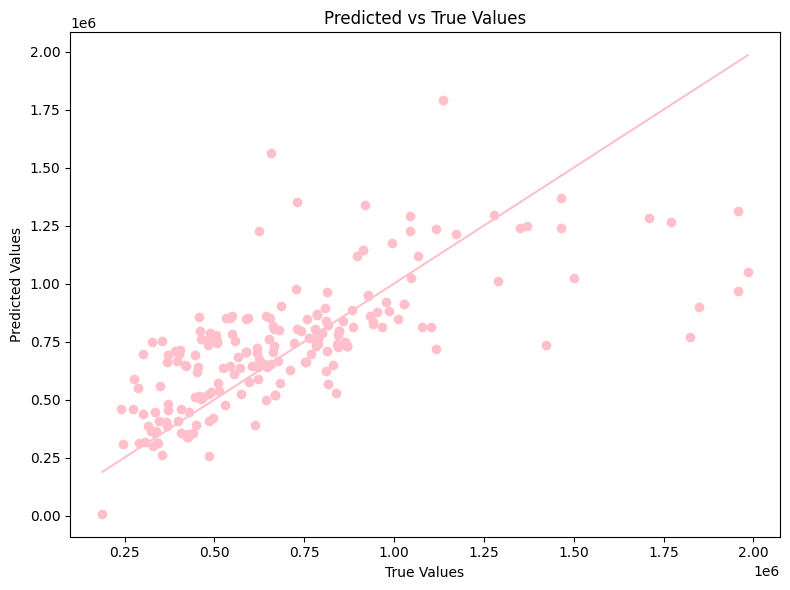

In [82]:
best_model = make_pipeline(PolynomialFeatures(degree=2), linear_model.LinearRegression())
# based on the performance metrics from the previous models, we are selecting the polynomial regression model with degree 2 as our best model to fit on the entire dataset and make predictions
best_model.fit(X_train, Y_train)
# the fit method is used to train the best polynomial regression model on the training data, where X_train is the independent variable and Y_train is the dependent variable

predicted_best = best_model.predict(X_test)
# the predicted_best variable contains the predicted prices for the test data based on the best polynomial regression model

plt.figure(figsize=(8, 6))
plt.scatter(Y_test, predicted_best, color='pink')
# plots a scatter plot of the true values (Y_test) against the predicted values (predicted_best) to visualize the performance of the best polynomial regression model

plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], color='pink')
# adds a reference line to the scatter plot that represents perfect predictions, where the predicted values would equal the true values

plt.title('Predicted vs True Values')
plt.xlabel('True Values')
plt.ylabel('Predicted Values')

plt.tight_layout()
plt.show()

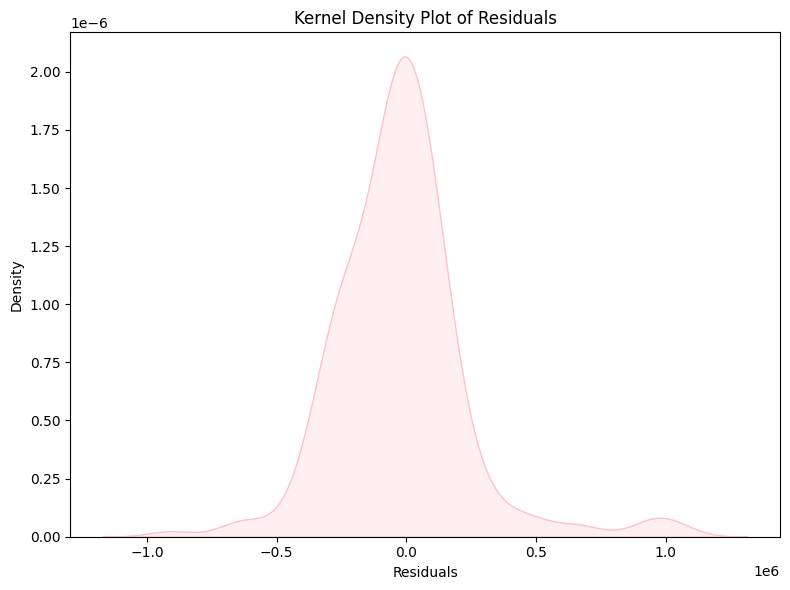

In [83]:
residuals = Y_test - predicted_best
# residuals are the errors or differences between the true values (Y_test) and the predicted values (predicted_best)

plt.figure(figsize=(8, 6))
sns.kdeplot(residuals, color='pink', fill=True)
# creates a kernel density plot of the residuals to visualize their distribution and assess the assumptions of the regression model, such as normality and homoscedasticity

plt.title('Kernel Density Plot of Residuals')
plt.xlabel('Residuals')

plt.tight_layout()
plt.show()

The residuals are roughly bell-shaped but also slightly right-skewed which means the model tends to underpredict high priced cars. The predicted values basically align with the diagonal line, this indicates that the model is able to estimate prices well. But a weakness is that the model still has noticeable scatter around the diagonal line, which is indicating prediction errors still remain.

**Q3.**
1. Find a dataset on a topic you're interested in. Some easy options are data.gov, kaggle.com, and data.world.

In [84]:
bmws = pd.read_csv('bmw.csv')
bmws.info() 

<class 'pandas.DataFrame'>
RangeIndex: 10781 entries, 0 to 10780
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         10781 non-null  str    
 1   year          10781 non-null  int64  
 2   price         10781 non-null  int64  
 3   transmission  10781 non-null  str    
 4   mileage       10781 non-null  int64  
 5   fuelType      10781 non-null  str    
 6   tax           10781 non-null  int64  
 7   mpg           10781 non-null  float64
 8   engineSize    10781 non-null  float64
dtypes: float64(2), int64(4), str(3)
memory usage: 758.2 KB


2. Clean the data and do some exploratory data analysis on key variables that interest you. Pick a particular target/outcome variable and features/predictors.

In [85]:
bmws.head(5)
# prints the first 5 rows of our data to get a better understanding of what it looks like

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,5 Series,2014,11200,Automatic,67068,Diesel,125,57.6,2.0
1,6 Series,2018,27000,Automatic,14827,Petrol,145,42.8,2.0
2,5 Series,2016,16000,Automatic,62794,Diesel,160,51.4,3.0
3,1 Series,2017,12750,Automatic,26676,Diesel,145,72.4,1.5
4,7 Series,2014,14500,Automatic,39554,Diesel,160,50.4,3.0


In [86]:
bmws.describe()
# gives us a statistical summary of our data, including count, mean, std, min, etc.

,year,price,mileage,tax,mpg,engineSize
count,10781.000000,10781.000000,10781.000000,10781.000000,10781.000000,10781.000000
mean,2017.078935,22733.408867,25496.986550,131.702068,56.399035,2.167767
std,2.349038,11415.528189,25143.192559,61.510755,31.336958,0.552054
min,1996.000000,1200.000000,1.000000,0.000000,5.500000,0.000000
25%,2016.000000,14950.000000,5529.000000,135.000000,45.600000,2.000000
50%,2017.000000,20462.000000,18347.000000,145.000000,53.300000,2.000000
75%,2019.000000,27940.000000,38206.000000,145.000000,62.800000,2.000000
max,2020.000000,123456.000000,214000.000000,580.000000,470.800000,6.600000


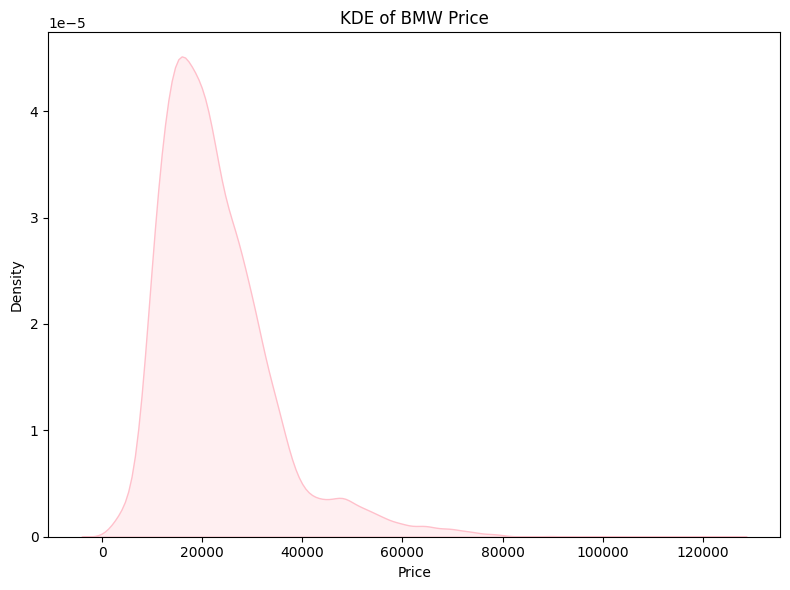

,price
model,
X7,69842.763636
8 Series,63997.794872
M5,57760.000000
i8,57012.588235
X6,43838.613208
M4,43274.232000
M2,43140.333333
X5,39651.196581
7 Series,36934.320755


In [87]:
bmws.columns = bmws.columns.str.strip()
# strip any leading/trailing whitespace from column names
bmws['log_price'] = np.log(bmws['price'])
# we are creating a new column called 'log_price' in our bmws DataFrame, which contains the natural logarithm of the 'price' column
bmws['log_mileage'] = np.log(bmws['mileage'] + 1)
# we are creating a new column called 'log_mileage' in our bmws DataFrame, which contains the natural logarithm of the 'mileage' column plus 1 to avoid taking the log of zero

plt.figure(figsize=(8, 6))
sns.kdeplot(bmws, x='price', color='pink', fill=True)

plt.title('KDE of BMW Price')
plt.xlabel('Price')
plt.ylabel('Density')

plt.tight_layout()
plt.show()

bmws.groupby('model')[['price']].mean().sort_values('price', ascending=False)
# shows us the average price for each BMW model, sorted in descending order to identify which models are the most expensive on average

3. Split the sample into an ~80% training set and a ~20% test set.

In [88]:
bmws_dummies = pd.get_dummies(bmws, columns=['model', 'transmission', 'fuelType'], drop_first=True, dtype='float')
# we are selecting the categorical columns (model, transmission, fuelType) and creating dummy variables for them, while dropping the first category to avoid the dummy variable trap

num_cols = ['year', 'log_mileage', 'tax', 'mpg', 'engineSize']
# we are selecting the numeric columns as our independent variables (X) for the next model
cat_cols = [col for col in bmws_dummies.columns if any(col.startswith(c) for c in ['model_', 'transmission_', 'fuelType_'])]
# we are creating a list of the column names that start with the specified prefixes, which correspond to the dummy variables for the categorical columns

X = bmws_dummies[num_cols + cat_cols]
# we are selecting both the numeric columns and the dummy variables for the car models, transmission types, and fuel types as our independent variables (X) for the next model
Y = bmws_dummies['price']
# the price as our dependent variable (Y)

combined = pd.concat([X, Y], axis=1).dropna()
# drops any rows with NaN values

X = combined[num_cols + cat_cols]
# we are selecting both the numeric columns and the dummy variables for the car models, transmission types, and fuel types as our independent variables (X) for the next model
Y = combined['price']
# the price as our dependent variable (Y)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.20, random_state=40)
# creating training and testing sets for our data, where test_size=.20 indicates that 20% of the data will be used for testing and random_state=40 ensures that the split is reproducible

4. Run a few regressions of your target/outcome variable on a variety of features/predictors. Compute the RMSE on the test set.

In [89]:
X_num = bmws_dummies[num_cols]
# we are selecting the numeric columns as our independent variables (X) for the next model, subsetting the numeric columns from our original data
Y = bmws_dummies['price']
# the price as our dependent variable (Y)

combined_num = pd.concat([X_num, Y], axis=1).dropna()
# we are creating a new DataFrame called combined_num that contains only the numeric columns and the price columns, also droping NAN values

X_num = combined_num[num_cols]
# new X_num variable that contains only the numeric columns from the combined_num DataFrame
Y_num = combined_num['price']
# new Y_num variable that contains the price column from the combined_num DataFrame, which will be used as the dependent variable in our next model

Xn_train, Xn_test, Yn_train, Yn_test = train_test_split(X_num, Y_num, test_size=0.20, random_state=40)
# creating training and testing sets for our numeric data, where test_size=.20 indicates that 20% of the data will be used for testing and random_state=40 ensures that the split is reproducible

modelA = linear_model.LinearRegression()
modelA.fit(Xn_train, Yn_train)
# the fit method is used to train the linear regression model on the training data, where Xn_train is the independent variable and Yn_train is the dependent variable
predA = modelA.predict(Xn_test)
# the predA variable contains the predicted prices for the test data based on the linear regression model trained on the numeric features

print('Numeric Model - R2:', r2_score(Yn_test, predA))
# the r2_score function is used to evaluate the performance of the linear regression model on the test data, where Yn_test are the true values and predA are the predicted values
print('Numeric Model - RMSE:', np.sqrt(mean_squared_error(Yn_test, predA)))
# prints the root mean squared error of the predictions on the test data, which is a measure of how well the model's predictions match the actual values in the test set

Numeric Model - R2: 0.6474499260182414
Numeric Model - RMSE: 6863.550891219939


In [90]:
modelB = linear_model.LinearRegression()
modelB.fit(X_train, Y_train)
# the fit method is used to train the linear regression model on the training data, where X_train is the independent variable and Y_train is the dependent variable

predB = modelB.predict(X_test)
# the predB variable contains the predicted prices for the test data based on the linear regression model trained on both numeric and categorical features

print('Combined Model - R2:', r2_score(Y_test, predB))
# the r2_score function is used to evaluate the performance of the linear regression model on the test data, where Y_test are the true values and predB are the predicted values
print('Combined Model - RMSE:', np.sqrt(mean_squared_error(Y_test, predB)))
# prints the root mean squared error of the predictions on the test data, which is a measure of how well the model's predictions match the actual values in the test set

Combined Model - R2: 0.8354204916205763
Combined Model - RMSE: 4689.497767782183


5. Which model performed the best, and why?

The model that performed the best was the combined model because it had the highest R2: 0.8354204916205763 and lowest RMSE: 4689.497767782183. This is because including both numeric variables (mileage, year, etc.) and categorical variables (model, fuel type, etc.) gave the model more information to predict price accurately.

6. What did you learn?

I learned that combining numeric and categorical variables together produces a better model than using either one by itself. I also learned that log transforming skewed variables like mileage and price helps the model perform better by reducing the influence of extreme values. I think overall it was interesting to see how the different models predicted R2 and RMSE, this lab helped me see how much models can be altered by small changes. 

### Dummy Variable Trap 


In linear regression with categorical variables you should be careful of the Dummy Variable Trap. 
The Dummy Variable trap is a scenario in which the independent variables are multicollinear - a 
scenario in which two or more variables are highly correlated; in simple terms one variable can 
be predicted from the others. This can produce singularity of a model, meaning your model just won't 
work. Read about it below:

Idea is to use dummy variable encoding with drop_first=True, this will omit one column from each 
category after converting categorical variable into dummy/indicator variables. You WILL NOT lose 
and relevant information by doing that simply because your all point in dataset can fully be 
explained by rest of the features.

Here is complete code on how you can do it for a "jobs" dataset

So you have your X features:

Age, Gender, Job, Classification 

And one numerical features that you are trying to predict:

Wage

First you need to split your initial dataset on input variables and prediction, 
assuming its pandas dataframe it would look like this:

Input variables (your dataset is bit different but whole code remains the same, 
you will put every column from dataset in X, except one that will go to Y. pd.get_dummies 
works without problem like that - it will just convert categorical variables and it won't 
touch numerical):

X = jobs[['Age','Gender','Job','Classification']]

Prediction:

Y = jobs['Wage']

Convert categorical variable into dummy/indicator variables and drop one in each category:

X = pd.get_dummies(data=X, drop_first=True)

So now if you check shape of X (X.shape) with drop_first=True you will see that it has 
4 columns less - one for each of your categorical variables.

You can now continue to use them in your linear model. For scikit-learn implementation it 
could look like this:


In [91]:
from sklearn import linear_model
from sklearn.model_selection import train_test_split
    
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = .20, random_state = 40)
    
regr = linear_model.LinearRegression() # Do not use fit_intercept = False if you have removed 
1 column after dummy encoding

regr.fit(X_train, Y_train)
predicted = regr.predict(X_test)

SyntaxError: invalid syntax (1680939890.py, line 7)

### Transformation versus Normalization

Use a **log transformation** when your data is strictly positive and heavily skewed towards larger values (right-skewed), while an **arcsinh transformation** is better suited for data with both positive and negative values, or when you need to handle potential zero values; **normalize** your data when you need to scale all values to a similar range, typically between 0 and 1, and especially when using algorithms sensitive to feature scale, but not necessarily to achieve a **normal distribution**. 
Key points about each transformation: 

    Log transformation: 

    Best for positively skewed data with large variations in magnitude. 

Useful when analyzing relative changes rather than absolute differences. 
Cannot handle negative values. 

Arcsinh transformation:

    Can handle both positive and negative data. 

Effective for data with extreme values on both ends of the spectrum. 
Often used when dealing with proportions or percentages near 0 or 1. 

Normalization: 

    Scales data to a common range, usually between 0 and 1. 

Useful when comparing features with different scales in machine learning algorithms. 
Does not necessarily transform the data distribution to be normal. 
